In [ ]:

# Task 1. Dataset Understanding
import numpy as np
import pandas as pd


#load and inspect the gathered data
data=pd.read_csv("/content/insurance2.csv")

#1.Display the first 5 records.
data.head()





,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


In [ ]:
#2. Display the last 5 records
data.tail()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
1333,50,1,30.97,3,0,1,10600.5483,0
1334,18,0,31.92,0,0,0,2205.9808,1
1335,18,0,36.85,0,0,2,1629.8335,1
1336,21,0,25.80,0,0,3,2007.9450,0
1337,61,0,29.07,0,1,1,29141.3603,1


In [ ]:
#3. Determine the number of rows and columns
rows, columns = data.shape

print("Number of rows:", rows)
print("Number of columns:", columns)


Number of rows: 1338
Number of columns: 8


In [ ]:
#4.Display all column names.
print(data.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'insuranceclaim'],
      dtype='object')


In [ ]:
#5.Display the data types
print(data.dtypes)

age                 int64
sex                 int64
bmi               float64
children            int64
smoker              int64
region              int64
charges           float64
insuranceclaim      int64
dtype: object


In [ ]:
#6.Identify missing values
print(data.isnull().sum())

age               0
sex               0
bmi               0
children          0
smoker            0
region            0
charges           0
insuranceclaim    0
dtype: int64


In [ ]:
#1.Which variables are numerical?
numerical_columns = data.select_dtypes(include=['int64', 'float64']).columns
print(list(numerical_columns))

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'insuranceclaim']


In [ ]:
#2.Which variables are categorical?
categorical_columns = data.select_dtypes(include=['object']).columns
print("Categorical Variables:")
print(list(categorical_columns))

Categorical Variables:
[]


In [ ]:
#What is the target variable
target_variable = 'insuranceclaim'
print("Target Variable:", target_variable)

Target Variable: insuranceclaim


In [23]:
#Is the target variable balanced?
import seaborn as sns
import matplotlib.pyplot as plt
# Count instances of each class
print(data['insuranceclaim'].value_counts())
# Percentage distribution
print(data['insuranceclaim'].value_counts(normalize=True) * 100)


insuranceclaim
1    783
0    555
Name: count, dtype: int64
insuranceclaim
1    58.520179
0    41.479821
Name: proportion, dtype: float64


/tmp/ipykernel_970/428241874.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='insuranceclaim', data=df, palette='Set2', ax=axes[3, 0])
/tmp/ipykernel_970/428241874.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


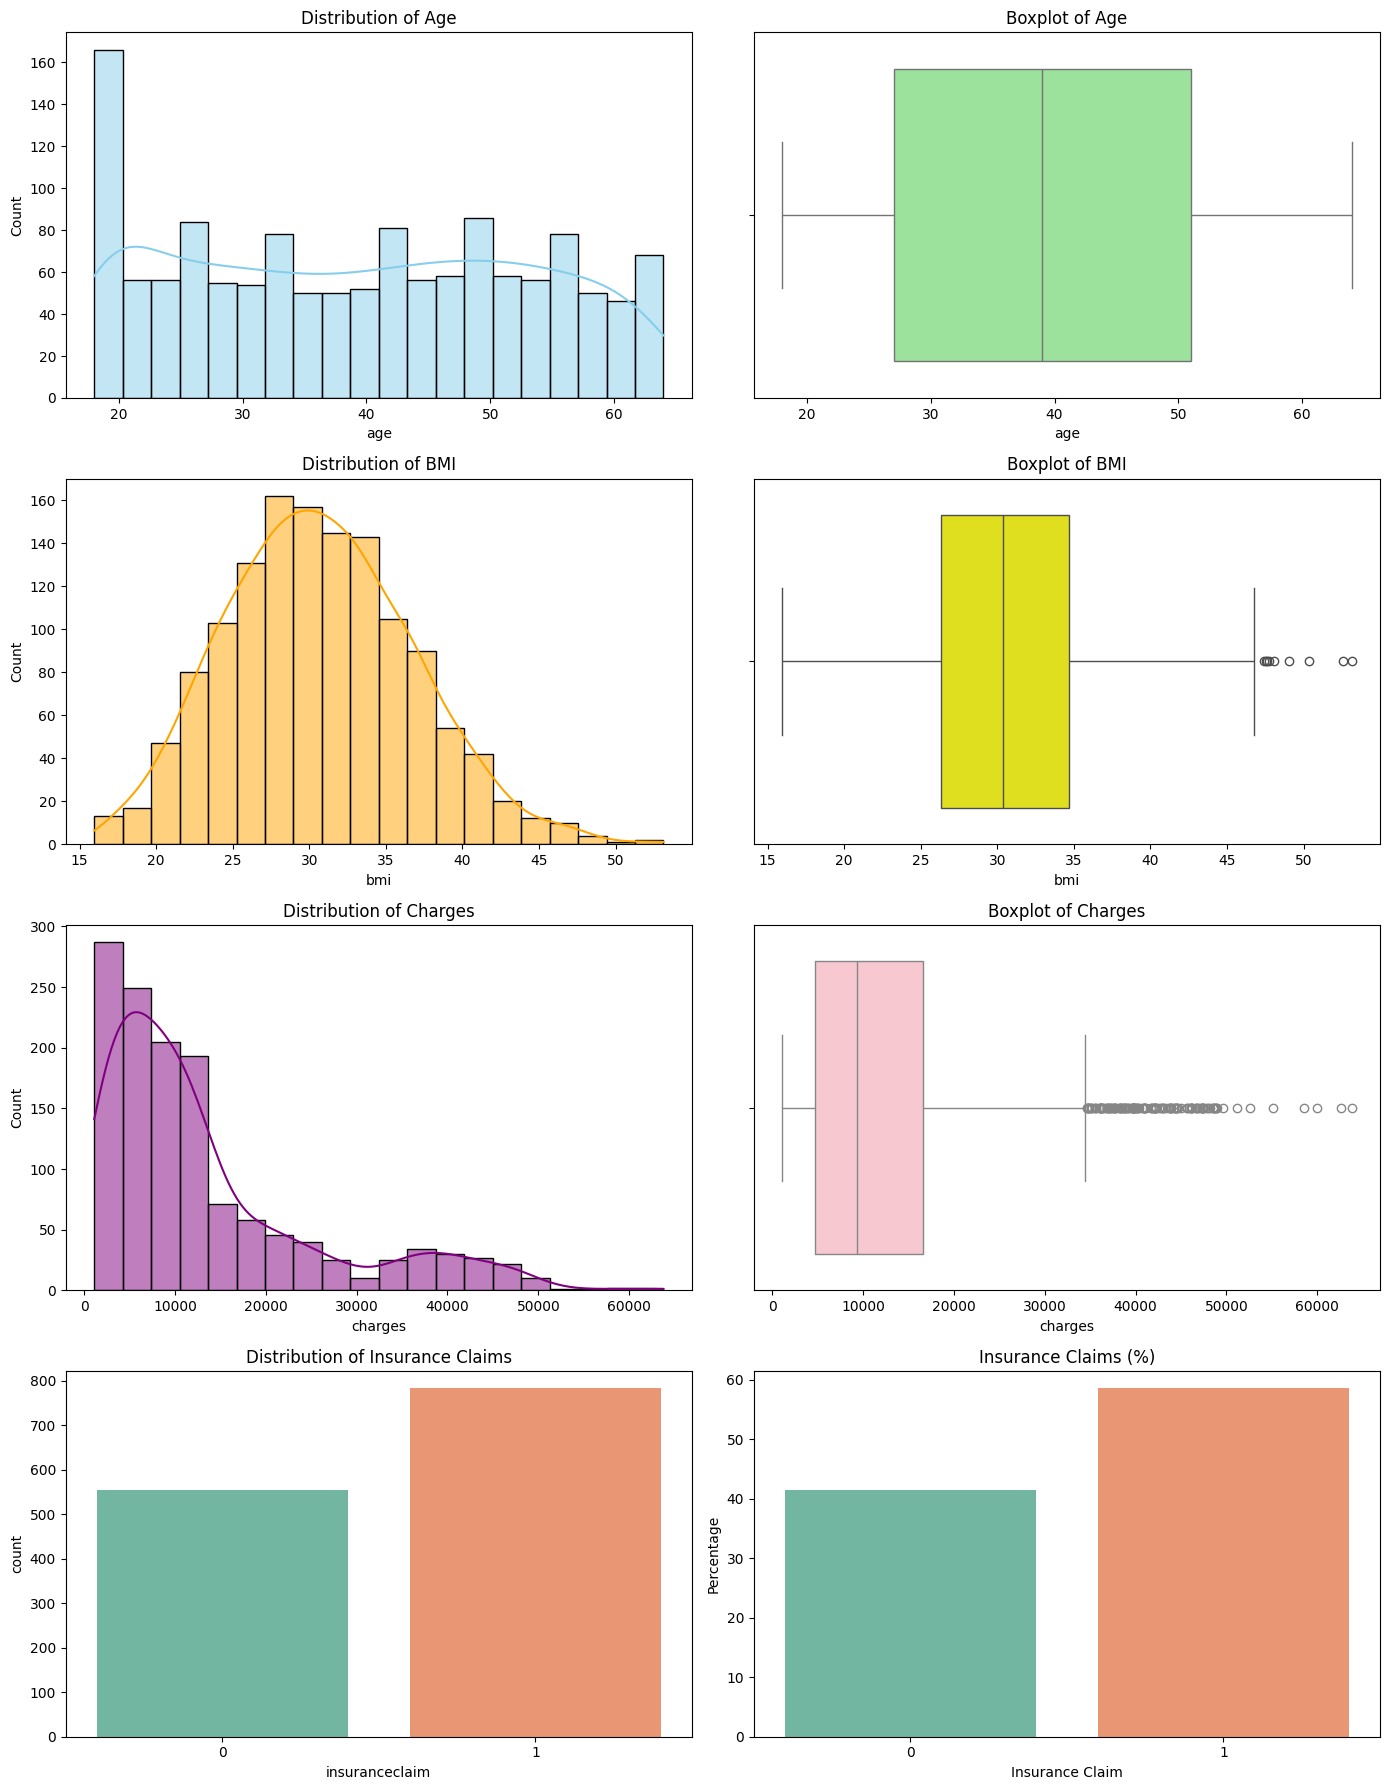

In [27]:
#Task Exploratory Data Analysis
#Perform appropriate exploratory data analysis.
#Create suitable visualizations for:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("insurance2.csv")

# Create subplots
fig, axes = plt.subplots(4, 2, figsize=(14, 18))

# AGE
sns.histplot(df['age'], bins=20, kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Age')

sns.boxplot(x=df['age'], color='lightgreen', ax=axes[0, 1])
axes[0, 1].set_title('Boxplot of Age')

# BMI
sns.histplot(df['bmi'], bins=20, kde=True, color='orange', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of BMI')

sns.boxplot(x=df['bmi'], color='yellow', ax=axes[1, 1])
axes[1, 1].set_title('Boxplot of BMI')

# CHARGES
sns.histplot(df['charges'], bins=20, kde=True, color='purple', ax=axes[2, 0])
axes[2, 0].set_title('Distribution of Charges')

sns.boxplot(x=df['charges'], color='pink', ax=axes[2, 1])
axes[2, 1].set_title('Boxplot of Charges')

# INSURANCE CLAIMS
sns.countplot(x='insuranceclaim', data=df, palette='Set2', ax=axes[3, 0])
axes[3, 0].set_title('Distribution of Insurance Claims')

# Percentage distribution of insurance claims
claim_percent = df['insuranceclaim'].value_counts(normalize=True) * 100

sns.barplot(
    x=claim_percent.index,
    y=claim_percent.values,
    palette='Set2',
    ax=axes[3, 1]
)
axes[3, 1].set_title('Insurance Claims (%)')
axes[3, 1].set_xlabel('Insurance Claim')
axes[3, 1].set_ylabel('Percentage')

plt.tight_layout()
plt.show()

In [28]:
#Task 3. Data Preprocessing
#Prepare the dataset for machine learning.
#1.Separate independent variables and the target variable.
import pandas as pd

# Load dataset
df = pd.read_csv("insurance2.csv")

# Independent variables (Features)
X = df.drop('insuranceclaim', axis=1)

# Target variable
y = df['insuranceclaim']

# Display the first 5 records
print("Independent Variables (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())

Independent Variables (X):
   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520

Target Variable (y):
0    1
1    1
2    0
3    0
4    1
Name: insuranceclaim, dtype: int64


In [30]:
#2.2. Encode categorical variables appropriately.
import pandas as pd

# Load dataset
df = pd.read_csv("insurance2.csv")

# Separate features and target
X = df.drop('insuranceclaim', axis=1)
y = df['insuranceclaim']

# One-Hot Encode categorical variables
X_encoded = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True)

# Display the encoded dataset
print(X_encoded.head())


   age     bmi  children      charges  sex_1  smoker_1  region_1  region_2  \
0   19  27.900         0  16884.92400  False      True     False     False   
1   18  33.770         1   1725.55230   True     False     False      True   
2   28  33.000         3   4449.46200   True     False     False      True   
3   33  22.705         0  21984.47061   True     False      True     False   
4   32  28.880         0   3866.85520   True     False      True     False   

   region_3  
0      True  
1     False  
2     False  
3     False  
4     False  


In [32]:
#3.Split the dataset into training and testing sets
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("insurance2.csv")

# Separate features and target
X = df.drop('insuranceclaim', axis=1)
y = df['insuranceclaim']

# Encode categorical variables
X = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True)

# Split the dataset: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1070, 9)
X_test shape : (268, 9)
y_train shape: (1070,)
y_test shape : (268,)


In [34]:
#4. Apply feature scaling where appropriate
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("insurance2.csv")

# Separate features and target
X = df.drop('insuranceclaim', axis=1)
y = df['insuranceclaim']

# Encode categorical variables
X = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True)

# Split the dataset: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


X_train shape: (1070, 9)
X_test shape : (268, 9)
y_train shape: (1070,)
y_test shape : (268,)


In [35]:
#Ensure that preprocessing does not result in data leakage
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("insurance2.csv")

# Separate features and target
X = df.drop('insuranceclaim', axis=1)
y = df['insuranceclaim']

# Encode categorical variables
X = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True)

# Split data FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale only numerical columns
numerical_cols = ['age', 'bmi', 'children', 'charges']

scaler = StandardScaler()

# Learn parameters from training data only
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Apply same transformation to test data
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Preprocessing completed without data leakage.")

Preprocessing completed without data leakage.


In [36]:
#Explain why preprocessing transformations should be learned from the training dataset rather than the
#complete dataset
Preprocessing transformations should be learned from the training dataset rather than the complete dataset to prevent data leakage. If information from the test dataset is used during preprocessing, the model gains access to data it would not have during real-world predictions, leading to overly optimistic performance estimates. Therefore, the dataset should first be split into training and testing sets, preprocessing techniques should be fitted on the training data only, and the resulting transformations should then be applied to the test data. This ensures a fair and realistic evaluation of the model.


In [38]:
#Task 4. Build Machine Learning Models
#1.Train the model
 #Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Build model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [39]:
# Generate predictions on test data
y_pred = model.predict(X_test)
print("Predictions:")
print(y_pred[:10])

Predictions:
[1 1 0 1 1 0 1 0 1 1]


In [40]:
#Generate prediction probabilities where applicable.
# Generate predictions on test data
y_pred = model.predict(X_test)
print("Predictions:")
print(y_pred[:10])

Predictions:
[1 1 0 1 1 0 1 0 1 1]


In [ ]:
#Evaluate the model.
